# Reinforcement Learning for Adaptive Glucose Regulation in Type 1 Diabetes

This notebook reformulates glucose prediction as a sequential decision-making problem.

Instead of predicting glucose, we train a Reinforcement Learning (RL) agent to learn adaptive behavioral strategies to maintain glucose within a safe clinical range.

The agent controls:

- Physical activity (steps)
- Carbohydrate intake (servings, where 1 serving = 10 g)

This is a methodological research study and not medical advice.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBRegressor
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv

from src.glucose_env import GlucoseEnvMultiAction

## Problem Reformulation

Traditional supervised learning answers:

"What will glucose be in 45 minutes?"

Reinforcement Learning answers:

"What should the patient do now to optimize future glucose levels?"

This transforms glucose prediction into a control problem.

In [2]:
# Load the trained XGBoost model
model = joblib.load("../models/xgb_glucose_model.pkl")

In [3]:
df = pd.read_csv("../data/HUPA0016P.csv", sep=";")

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# Glucose memory
df["glucose_lag1"] = df["glucose"].shift(1)
df["glucose_lag2"] = df["glucose"].shift(2)
df["glucose_ma_30"] = df["glucose"].rolling(6).mean()

# Interventions
df["carbs_45m"] = df["carb_input"].rolling(9).sum()
df["bolus_45m"] = df["bolus_volume_delivered"].rolling(9).sum()
df["steps_30m"] = df["steps"].rolling(6).sum()

# Other physiological variables
df["calories_30m"] = df["calories"].rolling(6).sum()
df["heart_rate_ma_30"] = df["heart_rate"].rolling(6).mean()
df["basal_rate_45m"] = df["basal_rate"].rolling(9).sum()

# Circadian
df["hour"] = df["time"].dt.hour

# Target
df["glucose_t+45"] = df["glucose"].shift(-9)

features = [
    "glucose_lag1",
    "glucose_lag2",
    "glucose_ma_30",
    "carbs_45m",
    "bolus_45m",
    "steps_30m",
    "calories_30m",
    "heart_rate_ma_30",
    "basal_rate_45m",
    "hour"
]

df_model = df[features + ["glucose_t+45"]].dropna()

## Environment Design

The predictive model acts as a physiological simulator.

State includes:
- Glucose lags
- Moving averages
- Insulin
- Activity
- Carbohydrates
- Heart rate
- Time of day

Action space:

- Steps ∈ [0, 2000]
- Carb servings ∈ [0, 6]
  (1 serving = 10 g)

Reward design:

- Penalize deviation from 110 mg/dL
- Strong penalty for hypoglycemia
- Penalize unnecessary interventions

In [4]:
# Create the environment
env = DummyVecEnv([lambda: GlucoseEnvMultiAction(df_model, model)])

c:\Users\amaiu\.conda\envs\metabolic-rl\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\amaiu\.conda\envs\metabolic-rl\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


## Reinforcement Learning Algorithm

We use Soft Actor-Critic (SAC), suitable for continuous control problems.

Advantages:
- Handles multi-dimensional continuous actions
- Stable learning
- Good exploration properties

The agent learns a policy π(a|s) mapping metabolic states to optimal interventions.

In [5]:
# Create PPO agent and train
agent = SAC(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    buffer_size=200000,
    batch_size=256,
    gamma=0.99,
    verbose=1
)

agent.learn(total_timesteps=500_000)
agent.save("models/sac_glucose_agent")

Using cpu device
---------------------------------
| time/              |          |
|    episodes        | 4        |
|    fps             | 24       |
|    time_elapsed    | 613      |
|    total_timesteps | 15264    |
| train/             |          |
|    actor_loss      | 8.26e+03 |
|    critic_loss     | 2.64e+05 |
|    ent_coef        | 6.36     |
|    ent_coef_loss   | -0.0972  |
|    learning_rate   | 0.0003   |
|    n_updates       | 15163    |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 8        |
|    fps             | 24       |
|    time_elapsed    | 1225     |
|    total_timesteps | 30528    |
| train/             |          |
|    actor_loss      | 1.25e+04 |
|    critic_loss     | 2.47e+05 |
|    ent_coef        | 7.18     |
|    ent_coef_loss   | -0.0144  |
|    learning_rate   | 0.0003   |
|    n_updates       | 30427    |
---------------------------------
-------------------------------

c:\Users\amaiu\.conda\envs\metabolic-rl\lib\site-packages\stable_baselines3\common\save_util.py:284: UserWarning: Path 'models' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


## Policy Evaluation

We evaluate the trained agent deterministically.

Metrics:

- Time-In-Range (70–180 mg/dL)
- Hypoglycemia rate
- Hyperglycemia rate
- Glucose variability

In [6]:
# Evaluate
eval_env = GlucoseEnvMultiAction(df_model, model)
obs, _ = eval_env.reset()

results = []

for _ in range(len(df_model)-1):
    action, _ = agent.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)

    results.append(info)

    if terminated:
        break

df_results = pd.DataFrame(results)

c:\Users\amaiu\.conda\envs\metabolic-rl\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\amaiu\.conda\envs\metabolic-rl\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [7]:
# TIR Vs Hypo Vs Hyper
glucose_preds = df_results["predicted_glucose"].values

tir = np.mean((glucose_preds >= 70) & (glucose_preds <= 180))
hypo = np.mean(glucose_preds < 70)
hyper = np.mean(glucose_preds > 180)
std = np.std(glucose_preds)

print("Time In Range:", tir)
print("Hypoglycemia:", hypo)
print("Hyperglycemia:", hyper)
print("Variability:", std)

Time In Range: 0.5555555555555556
Hypoglycemia: 0.1179245283018868
Hyperglycemia: 0.32651991614255765
Variability: 84.525604


## Policy Interpretation

To understand the learned behavior, we analyze average recommended steps and carb servings by glucose zone:

- Hypoglycemia (<70)
- In Range (70–180)
- Hyperglycemia (>180)

Clinically coherent behavior should:

- Recommend carb intake during hypoglycemia risk
- Increase physical activity during hyperglycemia
- Minimize interventions when in range

In [8]:
df_results

,predicted_glucose,steps_action,carb_servings_action
0,135.193008,42.293312,5.800451
1,198.913193,189.499908,2.349643
2,216.946609,1968.870850,5.198379
3,236.968887,1979.059326,5.202935
4,238.159103,1992.663086,5.655698
...,...,...,...
3811,100.022476,507.928619,4.322927
3812,101.167633,892.391235,2.211375
3813,95.172806,757.402771,1.141999
3814,90.554901,673.356628,1.722618


In [13]:
bins = [0, 70, 180, 400]
labels = ["Hypo", "In Range", "Hyper"]

df_results["zone"] = pd.cut(df_results["predicted_glucose"], bins=bins, labels=labels)

df_results.groupby("zone")[["steps_action", "carb_servings_action"]].mean()

C:\Users\amaiu\AppData\Local\Temp\ipykernel_21148\27843598.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_results.groupby("zone")[["steps_action", "carb_servings_action"]].mean()


,steps_action,carb_servings_action
zone,,
Hypo,508.419064,3.990317
In Range,812.565209,3.321305
Hyper,1687.688945,3.006478


## Limitations

- The simulator depends on a supervised model.
- No physiological equations are explicitly modeled.
- No real-world clinical validation.
- Results are dataset-dependent.

This work provides a methodological contribution, not medical advice.

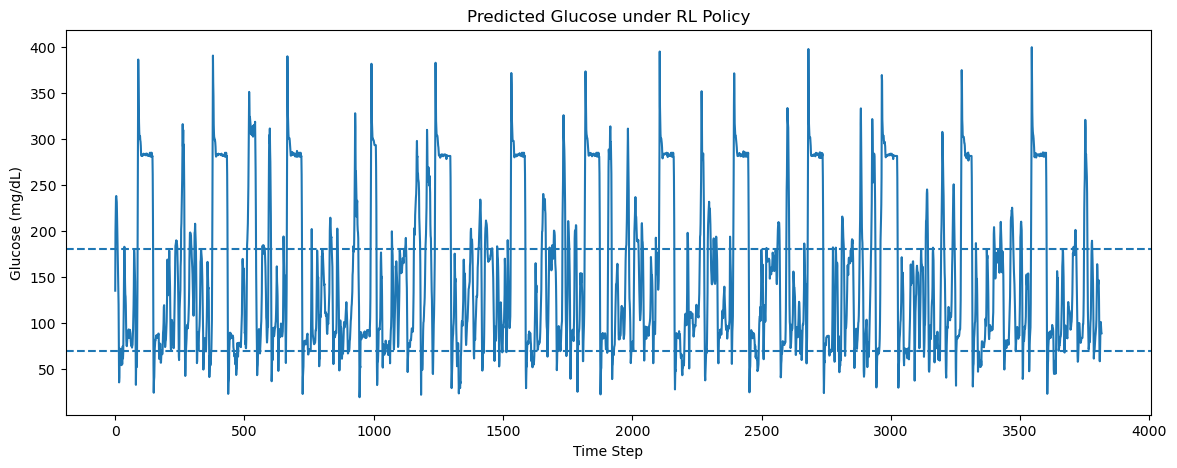

In [14]:
# Plot predicted glucose under RL policy
plt.figure(figsize=(14,5))
plt.plot(glucose_preds)
plt.axhline(70, linestyle="--")
plt.axhline(180, linestyle="--")
plt.title("Predicted Glucose under RL Policy")
plt.xlabel("Time Step")
plt.ylabel("Glucose (mg/dL)")
plt.show()

In [15]:
# TIR real vs RL
real_glucose = df_model["glucose_t+45"].values

tir_real = np.mean((real_glucose >= 70) & (real_glucose <= 180))

print("TIR real:", tir_real)
print("TIR RL:", tir)

TIR real: 0.5167627029858565
TIR RL: 0.5555555555555556


## Interpretation

RL achieves higher Time-In-Range compared to observed behavior,
this suggests that adaptive behavioral strategies learned through
Reinforcement Learning may improve metabolic control.

However, results depend on the accuracy of the predictive simulator
and require clinical validation.